<a href="https://colab.research.google.com/github/Toepatella/calibrated-selective-prediction-clinical-shift/blob/main/phase0_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Split Conformal Prediction

### Step 0.1.1 -- Split conformal, by hand

Goal: see distribution-free marginal coverage appear empirically.

We train one small classifier on a toy multi-class problem (synthetic Gaussian blobs -- swap in the CIFAR-10 `Net` from the classifier tutorial if you want a heavier example; the conformal procedure is identical either way). Then, for many random calibration/test splits, we:

  1. Compute nonconformity scores s_i = 1 - f_{y_i}(x_i) on a calibration set (held out, not used for training).
  2. Set q_hat = the ceil((n+1)(1-alpha))-th smallest calibration score.
  3. Form prediction sets on test points: {y : 1 - f_y(x) <= q_hat}.
  4. Measure the fraction of test points whose true label landed in the set.

Assumption used: exchangeability of (calibration, test) points -- nothing else. No assumption on the model, the data distribution, or correctness of f.

Pitfall avoided: we use the ceil((n+1)(1-alpha))-th order statistic (not the plain n-quantile). The "+1" is what gives the finite-sample guarantee; dropping it undercovers, especially for small n.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

### 1. A toy classifier

Synthetic Gaussian blobs, K classes in D dimensions. Trains in a couple seconds, which matters since we re-run the cal/test split many times. (If you'd rather use the CIFAR-10 `Net` from the classifier tutorial, train it once, set `model = net`, `X_pool, y_pool = <test set tensors>`, and skip straight to Section 2 -- the conformal code only assumes model(x) returns logits.)

In [ ]:
K = 5            # number of classes
D = 8            # feature dimension
N_TRAIN = 2000
N_POOL = 4000    # pool we'll repeatedly re-split into calibration/test

def make_gaussian_blobs(n, K, D, class_sep=2.5):
    centers = np.random.randn(K, D) * class_sep
    y = np.random.randint(0, K, size=n)
    X = centers[y] + np.random.randn(n, D)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long), centers

X_train, y_train, centers = make_gaussian_blobs(N_TRAIN, K, D)

# pool drawn from the SAME centers so train/pool are exchangeable
y_pool = torch.randint(0, K, (N_POOL,))
X_pool = torch.tensor(centers[y_pool.numpy()], dtype=torch.float32) + torch.randn(N_POOL, D)

In [ ]:
class Net(nn.Module):
    def __init__(self, d_in, k_out):
        super().__init__()
        self.fc1 = nn.Linear(d_in, 32)
        self.fc2 = nn.Linear(32, 32)
        self.fc3 = nn.Linear(32, k_out)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

In [ ]:
model = Net(D, K)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.05, momentum=0.9)

for epoch in range(200):
    optimizer.zero_grad()
    logits = model(X_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()

print(f"final train loss: {loss.item():.4f}")
with torch.no_grad():
    train_acc = (model(X_train).argmax(1) == y_train).float().mean().item()
print(f"train accuracy: {train_acc:.3f}")

final train loss: 0.0043
train accuracy: 0.998


### 2. Split conformal, by hand

Note this classifier is deliberately imperfect (overlapping Gaussian blobs) -- conformal coverage should hold regardless of how good or bad it is, which is the whole point: the guarantee comes from exchangeability of the calibration/test split, not from model accuracy.

In [ ]:
ALPHA = 0.10  # target miscoverage -> we want ~90% coverage

@torch.no_grad()
def softmax_probs(model, X):
    return F.softmax(model(X), dim=1)

def conformal_quantile(scores, alpha):
    """q_hat = ceil((n+1)(1-alpha))-th smallest score, clipped to <= 1."""
    n = len(scores)
    k = int(np.ceil((n + 1) * (1 - alpha)))
    k = min(k, n)  # if k > n, q_hat is effectively infinite (use max score)
    return np.sort(scores)[k - 1]

In [ ]:
def one_split_coverage(model, X_pool, y_pool, n_cal, alpha):
    n_pool = X_pool.shape[0]
    perm = torch.randperm(n_pool)
    cal_idx, test_idx = perm[:n_cal], perm[n_cal:]

    X_cal, y_cal = X_pool[cal_idx], y_pool[cal_idx]
    X_test, y_test = X_pool[test_idx], y_pool[test_idx]

    probs_cal = softmax_probs(model, X_cal)
    s_cal = (1 - probs_cal[torch.arange(len(y_cal)), y_cal]).numpy()
    q_hat = conformal_quantile(s_cal, alpha)

    probs_test = softmax_probs(model, X_test)
    nonconf_test = 1 - probs_test  # shape (n_test, K): nonconformity per candidate label
    pred_sets = nonconf_test <= q_hat  # bool mask, True where label y is included

    covered = pred_sets[torch.arange(len(y_test)), y_test]
    avg_set_size = pred_sets.float().sum(dim=1).mean().item()
    return covered.float().mean().item(), avg_set_size, q_hat

In [ ]:
N_SPLITS = 500
N_CAL = 300

coverages = []
set_sizes = []
for _ in range(N_SPLITS):
    cov, size, _ = one_split_coverage(model, X_pool, y_pool, N_CAL, ALPHA)
    coverages.append(cov)
    set_sizes.append(size)

coverages = np.array(coverages)
print(f"target coverage: {1 - ALPHA:.3f}")
print(f"mean realized coverage over {N_SPLITS} splits: {coverages.mean():.4f}")
print(f"std of realized coverage: {coverages.std():.4f}")
print(f"mean prediction-set size: {np.mean(set_sizes):.2f} (of {K} classes)")

target coverage: 0.900
mean realized coverage over 500 splits: 0.9003
std of realized coverage: 0.0190
mean prediction-set size: 0.90 (of 5 classes)


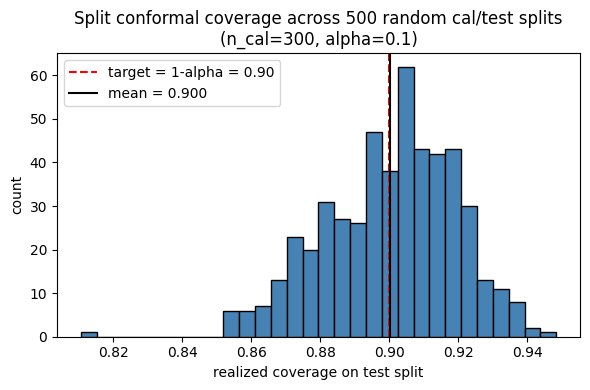

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(coverages, bins=30, color="steelblue", edgecolor="black")
plt.axvline(1 - ALPHA, color="red", linestyle="--", label=f"target = 1-alpha = {1-ALPHA:.2f}")
plt.axvline(coverages.mean(), color="black", linestyle="-", label=f"mean = {coverages.mean():.3f}")
plt.xlabel("realized coverage on test split")
plt.ylabel("count")
plt.title(f"Split conformal coverage across {N_SPLITS} random cal/test splits\n(n_cal={N_CAL}, alpha={ALPHA})")
plt.legend()
plt.tight_layout()
plt.show()

### 3. The pitfall, demonstrated

Use the plain n-th smallest score (no "+1") instead of ceil((n+1)(1-alpha)), and watch mean coverage fall measurably below 1-alpha -- most noticeably at small n_cal.

In [ ]:
def buggy_quantile(scores, alpha):
    """WRONG: uses ceil(n * (1 - alpha)) instead of ceil((n+1) * (1 - alpha)). Undercovers."""
    n = len(scores)
    k = int(np.ceil(n * (1 - alpha)))
    k = min(max(k, 1), n)
    return np.sort(scores)[k - 1]

In [ ]:
def one_split_coverage_buggy(model, X_pool, y_pool, n_cal, alpha):
    n_pool = X_pool.shape[0]
    perm = torch.randperm(n_pool)
    cal_idx, test_idx = perm[:n_cal], perm[n_cal:]
    X_cal, y_cal = X_pool[cal_idx], y_pool[cal_idx]
    X_test, y_test = X_pool[test_idx], y_pool[test_idx]

    probs_cal = softmax_probs(model, X_cal)
    s_cal = (1 - probs_cal[torch.arange(len(y_cal)), y_cal]).numpy()
    q_hat = buggy_quantile(s_cal, alpha)

    probs_test = softmax_probs(model, X_test)
    pred_sets = (1 - probs_test) <= q_hat
    covered = pred_sets[torch.arange(len(y_test)), y_test]
    return covered.float().mean().item()

In [ ]:
N_CAL_SMALL = 30  # small n makes the +1 effect obvious
buggy_cov = [one_split_coverage_buggy(model, X_pool, y_pool, N_CAL_SMALL, ALPHA) for _ in range(N_SPLITS)]
correct_cov = [one_split_coverage(model, X_pool, y_pool, N_CAL_SMALL, ALPHA)[0] for _ in range(N_SPLITS)]

print(f"n_cal = {N_CAL_SMALL}, target = {1 - ALPHA:.3f}")
print(f"correct (+1) mean coverage:   {np.mean(correct_cov):.4f}")
print(f"buggy (no +1) mean coverage:  {np.mean(buggy_cov):.4f}")

n_cal = 30, target = 0.900
correct (+1) mean coverage:   0.9025
buggy (no +1) mean coverage:  0.8714


### Done-when check

- Mean realized coverage above (Section 2) should sit close to 1-alpha -- run the script a few times / increase N_SPLITS if it looks off.
- The only assumption used anywhere in one_split_coverage is that calibration and test points are exchangeable draws from the same pool -- nothing about the model's accuracy, the data's distribution shape, or the number of classes was assumed.
- Quantile to recall from memory: q_hat = the ceil((n+1)(1-alpha))-th smallest calibration nonconformity score (Section 3 shows what breaks without the "+1").

## Conformal Risk Control (CRC)

### Step 0.1.2 -- Conformal risk control

Goal: control an *expected loss*, not just miscoverage.

Split conformal (Step 0.1.1) controls one specific risk: the probability the true label falls outside the set. CRC (Angelopoulos, Bates, Fisch, Lei, Schuster, *Conformal Risk Control*, ICLR 2024 -- https://github.com/aangelopoulos/conformal-risk) generalizes this to **any bounded, monotone loss**.

Setup. Pick a threshold parameter `lambda` that grows the prediction set as it increases, and a per-example loss `L_i(lambda)` that is

  - **monotone non-increasing in lambda** (bigger set -> smaller loss), and
  - **bounded**: `0 <= L_i(lambda) <= B` for some finite `B`.

Given calibration losses, CRC picks

    lambda_hat = inf { lambda : (n/(n+1)) * Rhat_n(lambda) + B/(n+1) <= alpha }

where `Rhat_n(lambda) = (1/n) sum_i L_i(lambda)` is the empirical calibration risk. The theorem guarantees

    E[ L_test(lambda_hat) ] <= alpha.

When `L_i(lambda) = 1{ y_i not in C_lambda(x_i) }` (the miscoverage indicator, `B = 1`), CRC reduces exactly to split conformal -- so Step 0.1.1 is the special case. Below we use a genuinely different loss to show the generality.

In [ ]:
# Faithful reproduction of core/get_lhat.py from aangelopoulos/conformal-risk.
# calib_loss_table: (n_cal, n_lambda). Columns MUST run from SMALL loss to LARGE
#   loss -- i.e. lambdas arranged so the set shrinks (loss grows) as the column
#   index increases. lambdas: matching 1-D array. B: the loss upper bound.
# Returns the tightest lambda_hat whose inflated empirical risk
#   (n/(n+1)) * Rhat(lambda) + B/(n+1) is still <= alpha.
def get_lhat(calib_loss_table, lambdas, alpha, B=1):
    n = calib_loss_table.shape[0]
    rhat = calib_loss_table.mean(axis=0)
    lhat_idx = max(np.argmax(((n / (n + 1)) * rhat + B / (n + 1)) >= alpha) - 1, 0)
    return lambdas[lhat_idx]


# Thin alias matching the task's naming.
def crc(calib_loss_table, lambdas, alpha, B=1.0):
    return get_lhat(calib_loss_table, lambdas, alpha, B)

### A multilabel toy (so the loss isn't just 0/1 coverage)

In the single-label problem of Step 0.1.1 the only natural per-example loss is the miscoverage indicator -- which just gives back conformal prediction. To exercise CRC on something different we switch to **multilabel** classification: each `x` has a *set* of true labels, and we control the **false-negative rate (FNR)** -- the fraction of an example's true labels we miss.

  - Prediction set at threshold lambda:  `C_lambda(x) = { k : f_k(x) >= 1 - lambda }`.
    lambda = 0 -> threshold 1 -> ~empty set; lambda = 1 -> threshold 0 -> all labels.
  - Loss:  `L_i(lambda) = 1 - |true labels kept| / |true labels|`  (FNR for example i).

This loss is **non-increasing in lambda** (a bigger set can only recover more true labels) and **bounded by B = 1**, so the vanilla CRC bound applies. We guarantee at least one positive label per example so the FNR denominator is never zero.

In [ ]:
# --- synthetic multilabel data: shared generative weights so train/pool are exchangeable ---
L = 10        # number of candidate labels
D2 = 20       # feature dim
N_ML_TRAIN = 3000
N_ML_POOL = 5000

torch.manual_seed(1)

def make_multilabel(n, W, b):
    L, D2 = W.shape
    X = torch.randn(n, D2)
    probs = torch.sigmoid(X @ W.T + b)
    Y = (torch.rand(n, L) < probs).float()
    empty = Y.sum(1) == 0
    if empty.any():
        Y[empty, probs[empty].argmax(1)] = 1.0   # guarantee >=1 positive (FNR well-defined)
    return X, Y

W_true = torch.randn(L, D2)
b_true = torch.randn(L) - 1.0                     # bias toward sparser label sets
X_ml_train, Y_ml_train = make_multilabel(N_ML_TRAIN, W_true, b_true)
X_ml_pool,  Y_ml_pool  = make_multilabel(N_ML_POOL,  W_true, b_true)

# --- train a small multilabel classifier (independent sigmoids via BCE) ---
ml_model = nn.Sequential(nn.Linear(D2, 64), nn.ReLU(), nn.Linear(64, L))
opt = optim.Adam(ml_model.parameters(), lr=1e-2)
bce = nn.BCEWithLogitsLoss()
for epoch in range(300):
    opt.zero_grad()
    bce_loss = bce(ml_model(X_ml_train), Y_ml_train)
    bce_loss.backward()
    opt.step()
print(f"avg true labels/example: {Y_ml_train.sum(1).mean():.2f}")
print(f"final BCE: {bce_loss.item():.4f}")


@torch.no_grad()
def label_probs(model, X):
    return torch.sigmoid(model(X))


# FNR per (example, lambda) -> (n, n_lambda) numpy array.
def fnr_loss_table(probs, Y, lambdas):
    thresh = 1 - lambdas                                              # (G,)
    included = probs[:, :, None] >= torch.tensor(thresh, dtype=probs.dtype)[None, None, :]
    tp = (Y[:, :, None].bool() & included).sum(1).float()            # true labels kept: (n, G)
    npos = Y.sum(1, keepdim=True)                                     # (n, 1), >= 1
    return (1 - tp / npos).numpy()


# lambdas DESCENDING: 1.0 (biggest set, smallest loss) -> 0.0 (smallest set, largest loss),
# so the loss-table columns run small-loss -> large-loss as get_lhat expects.
G = 100
lambdas = np.linspace(1.0, 0.0, G)
ALPHA_CRC = 0.10                 # control expected FNR at 10% (keep >= 90% of true labels on avg)
B = 1.0

# sanity: loss really is monotone in lambda and spans [0, ~1]
_col = fnr_loss_table(label_probs(ml_model, X_ml_pool), Y_ml_pool, lambdas).mean(0)
print("monotone non-increasing in lambda:", bool(np.all(np.diff(_col) >= -1e-9)))
print(f"mean loss at lambda=1: {_col[0]:.3f}   at lambda=0: {_col[-1]:.3f}")

### Calibrate on one split, test on the rest

`get_lhat` reads the calibration loss table, inflates the empirical risk by the `(n, B)` finite-sample correction, and returns the tightest `lambda_hat` that keeps it `<= alpha`. We then build sets on the held-out test points and measure the realized FNR.

In [ ]:
def one_split_crc(model, X_pool, Y_pool, n_cal, lambdas, alpha, B):
    perm = torch.randperm(X_pool.shape[0])
    cal_idx, test_idx = perm[:n_cal], perm[n_cal:]

    cal_tbl = fnr_loss_table(label_probs(model, X_pool[cal_idx]), Y_pool[cal_idx], lambdas)
    lhat = crc(cal_tbl, lambdas, alpha, B)                 # <-- CRC threshold

    probs_test = label_probs(model, X_pool[test_idx])
    incl = probs_test >= (1 - lhat)
    tp = (Y_pool[test_idx].bool() & incl).sum(1).float()
    npos = Y_pool[test_idx].sum(1)
    test_fnr = (1 - tp / npos).mean().item()
    avg_set = incl.float().sum(1).mean().item()
    return test_fnr, lhat, avg_set

fnr, lhat, sz = one_split_crc(ml_model, X_ml_pool, Y_ml_pool, 1000, lambdas, ALPHA_CRC, B)
print(f"lambda_hat = {lhat:.3f}")
print(f"realized test FNR = {fnr:.4f}   (target alpha = {ALPHA_CRC})")
print(f"avg prediction-set size = {sz:.2f} of {L} labels")

### Does E[loss] land at or below alpha?

CRC controls the loss *in expectation over the calibration draw* -- `lambda_hat` is itself random (it depends on which points landed in calibration). So the right check is the **mean realized test risk across many random cal/test splits**, not any single split.

In [ ]:
N_SPLITS_CRC = 300
N_CAL_CRC = 1000

risks = np.array([
    one_split_crc(ml_model, X_ml_pool, Y_ml_pool, N_CAL_CRC, lambdas, ALPHA_CRC, B)[0]
    for _ in range(N_SPLITS_CRC)
])

print(f"target alpha = {ALPHA_CRC}")
print(f"mean realized test FNR over {N_SPLITS_CRC} splits: {risks.mean():.4f}  (should be <= {ALPHA_CRC})")
print(f"std: {risks.std():.4f}")
print(f"fraction of individual splits above alpha: {(risks > ALPHA_CRC).mean():.2f}  "
      f"(per-draw can exceed alpha; only the MEAN is guaranteed)")

plt.figure(figsize=(6, 4))
plt.hist(risks, bins=30, color="seagreen", edgecolor="black")
plt.axvline(ALPHA_CRC, color="red", linestyle="--", label=f"alpha = {ALPHA_CRC}")
plt.axvline(risks.mean(), color="black", linestyle="-", label=f"mean = {risks.mean():.3f}")
plt.xlabel("realized test FNR (expected loss)")
plt.ylabel("count")
plt.title(f"CRC controls E[loss] across {N_SPLITS_CRC} cal/test splits\n(n_cal={N_CAL_CRC}, alpha={ALPHA_CRC}, B={B})")
plt.legend()
plt.tight_layout()
plt.show()

### Done-when check

- **What CRC controls.** `E[ L_test(lambda_hat) ] <= alpha`, where the expectation is taken over **both** the test point **and the calibration draw** (because `lambda_hat` is a random function of the calibration set). The histogram above makes this concrete: the *mean* sits at/just below alpha, while a sizable fraction of individual splits land above it. That is allowed -- CRC is a statement about the average over calibration draws, not a per-calibration (conditional) promise. Same flavor as conformal's *marginal* coverage in Step 0.1.1.
- **Why that differs from a per-model guarantee.** A per-model / per-calibration guarantee would require `E[L_test(lambda_hat) | calibration set] <= alpha` for *every* calibration set. CRC does not give that; it gives control only after also averaging over the calibration randomness. Fix one unlucky calibration draw and the conditional risk can exceed alpha.
- **Pitfall.** The vanilla bound needs the loss to be (i) **monotone** in lambda and (ii) **bounded** by a known `B` (we used FNR: monotone non-increasing, `B = 1`). Lose monotonicity (so the empirical risk isn't a clean monotone function of lambda) or boundedness (so the `B/(n+1)` correction is wrong) and the guarantee no longer holds.
- **Recall the threshold from memory:** `lambda_hat = inf { lambda : (n/(n+1)) * Rhat_n(lambda) + B/(n+1) <= alpha }`; with the 0/1 miscoverage loss and `B = 1` this collapses back to the Step 0.1.1 conformal quantile.

## Selective Prediction

### Step 0.1.3 -- Selective prediction + why naive filtering breaks

Goal: build the abstain gate and feel the selection bias.

A *selective* predictor is allowed to say "I don't know." It pairs the classifier `f` with a **gate**

    g(x) = 1[ u(x) <= tau ]      # 1 = predict, 0 = abstain

where `u(x)` is an uncertainty score -- here either **softmax-response** `u(x) = 1 - max_y f_y(x)` (small = confident) or **entropy** `u(x) = -sum_y f_y(x) log f_y(x)`. Lower `tau` -> abstain more -> act only on the points the model is surest about.

We will (a) build the gate, (b) draw the **risk-coverage curve** and compute **AURC**, then (c) spring the trap: a conformal predictor calibrated on *all* data does **not** keep its `1 - alpha` guarantee once you look only at the *accepted* points.

> **Pitfall flagged up front (two different axes).** "Coverage" is overloaded here:
> - *selective coverage* = the fraction of points we accept (don't abstain on);
> - *conformal coverage* = the fraction of accepted points whose true label is in the prediction set.
> A model can have a beautiful risk-coverage curve and still have conformal coverage on the accepted region nowhere near `1 - alpha`. We report **both** and never plot them on the same axis.

### A harder toy (so confidence actually varies)

The Step 0.1.1 blobs are ~99.8% accurate -- there's nothing to abstain on. We reuse `make_gaussian_blobs` with a much smaller `class_sep` so the classes overlap, the model makes real mistakes, and `u(x)` carries information about which points are risky.

In [ ]:
torch.manual_seed(0)
np.random.seed(0)

SEP = 0.8                          # overlapping blobs -> ~83% accuracy, real uncertainty
Xs_train, ys_train, centers_s = make_gaussian_blobs(4000, K, D, class_sep=SEP)
ys_pool = torch.randint(0, K, (8000,))
Xs_pool = torch.tensor(centers_s[ys_pool.numpy()], dtype=torch.float32) + torch.randn(8000, D)

sel_model = Net(D, K)
opt = optim.SGD(sel_model.parameters(), lr=0.05, momentum=0.9)
crit = nn.CrossEntropyLoss()
for epoch in range(200):
    opt.zero_grad()
    loss = crit(sel_model(Xs_train), ys_train)
    loss.backward()
    opt.step()

probs_sel = softmax_probs(sel_model, Xs_pool)
preds = probs_sel.argmax(1)
correct = (preds == ys_pool).numpy().astype(float)
u_sr = (1 - probs_sel.max(1).values).numpy()                         # softmax-response uncertainty
u_ent = (-(probs_sel * torch.log(probs_sel + 1e-12)).sum(1)).numpy()  # entropy uncertainty
print(f"pool accuracy: {correct.mean():.3f}  (so full-coverage selective risk ~= {1-correct.mean():.3f})")

### (a)+(b) The abstain gate and the risk-coverage curve

Sweep the gate from "abstain on everything" to "accept everything." Accepting the most-confident points first traces the **risk-coverage curve**: x = selective coverage (fraction accepted), y = **selective risk** (top-1 error rate *among accepted points*). A good uncertainty score pushes the curve down-and-right: low risk while still accepting a lot.

**AURC** (area under the risk-coverage curve) summarizes it in one number -- lower is better. We compute it for both softmax-response and entropy.

In [ ]:
def risk_coverage(u, correct):
    order = np.argsort(u)                               # accept lowest-uncertainty first
    cs = correct[order]
    k = np.arange(1, len(u) + 1)
    coverage = k / len(u)                               # fraction accepted
    sel_risk = 1 - np.cumsum(cs) / k                    # error rate on the accepted prefix
    return coverage, sel_risk

def aurc(u, correct):
    return risk_coverage(u, correct)[1].mean()          # empirical area under the curve

cov_sr, risk_sr = risk_coverage(u_sr, correct)
cov_ent, risk_ent = risk_coverage(u_ent, correct)
print(f"AURC (softmax-response): {aurc(u_sr, correct):.4f}")
print(f"AURC (entropy):          {aurc(u_ent, correct):.4f}")

# the gate at one operating point: accept the 50% most confident
tau = float(np.quantile(u_sr, 0.5))
g = u_sr <= tau                                         # g(x) = 1[u(x) <= tau]
print(f"\ngate at tau={tau:.3f}: selective coverage={g.mean():.3f} (fraction accepted), "
      f"selective risk={1 - correct[g].mean():.3f} (error on accepted)")

plt.figure(figsize=(6, 4))
plt.plot(cov_sr, risk_sr, label=f"softmax-response (AURC={aurc(u_sr, correct):.3f})")
plt.plot(cov_ent, risk_ent, label=f"entropy (AURC={aurc(u_ent, correct):.3f})", linestyle="--")
plt.xlabel("selective coverage (fraction accepted)")
plt.ylabel("selective risk (error on accepted)")
plt.title("Risk-coverage curve")
plt.legend()
plt.tight_layout()
plt.show()

### (c) The trap: calibrate conformal on all data, evaluate on accepted only

Now combine the gate with the split-conformal predictor from Step 0.1.1. We calibrate `q_hat` on **all** calibration points (so it's valid *marginally*), build sets `C(x) = {y : 1 - f_y(x) <= q_hat}` on test, and then ask: among the points the gate **accepts**, what is the conformal coverage?

Across many splits we record coverage on the full test set, on the accepted subset, and on the rejected subset.

In [ ]:
ALPHA = 0.10
torch.manual_seed(1)
np.random.seed(1)
N_SPLITS, N_CAL = 150, 2000
accept_fracs = np.linspace(0.9, 0.2, 8)   # gate tau = this quantile of pool uncertainty

results = {}   # accept_frac -> mean coverages (full / accepted-q_all / rejected / accepted-q_accepted)
for af in accept_fracs:
    tau_af = float(np.quantile(u_sr, af))
    full, acc_all, rej, acc_fix = [], [], [], []
    for _ in range(N_SPLITS):
        perm = torch.randperm(Xs_pool.shape[0])
        cal, test = perm[:N_CAL], perm[N_CAL:]
        p_cal = softmax_probs(sel_model, Xs_pool[cal]); yc = ys_pool[cal]
        p_test = softmax_probs(sel_model, Xs_pool[test]); yt = ys_pool[test]
        s_cal = (1 - p_cal[torch.arange(len(yc)), yc]).numpy()
        s_test = (1 - p_test[torch.arange(len(yt)), yt]).numpy()
        u_cal = (1 - p_cal.max(1).values).numpy()
        u_test = (1 - p_test.max(1).values).numpy()

        q_all = conformal_quantile(s_cal, ALPHA)         # calibrate on ALL cal points
        covered = s_test <= q_all
        amask = u_test <= tau_af                         # gate on test
        full.append(covered.mean())
        acc_all.append(covered[amask].mean())
        rej.append(covered[~amask].mean())

        q_acc = conformal_quantile(s_cal[u_cal <= tau_af], ALPHA)  # FIX (used in next section)
        acc_fix.append((s_test[amask] <= q_acc).mean())
    results[af] = dict(full=np.mean(full), acc_all=np.mean(acc_all),
                       rej=np.mean(rej), acc_fix=np.mean(acc_fix))

print(f"target conformal coverage = {1 - ALPHA}\n")
print(f"{'accept%':>8}{'full':>9}{'accepted':>11}{'rejected':>11}")
for af in (0.7, 0.5, 0.3):
    r = results[min(accept_fracs, key=lambda x: abs(x - af))]
    print(f"{af*100:7.0f}%{r['full']:9.3f}{r['acc_all']:11.3f}{r['rej']:11.3f}")

afs = sorted(results)
plt.figure(figsize=(6, 4))
plt.plot(afs, [results[a]['acc_all'] for a in afs], "o-", label="coverage on ACCEPTED (q_all)")
plt.plot(afs, [results[a]['rej'] for a in afs], "s-", label="coverage on rejected (q_all)")
plt.plot(afs, [results[a]['full'] for a in afs], "^-", label="coverage on full test")
plt.axhline(1 - ALPHA, color="red", linestyle="--", label=f"target 1-alpha = {1-ALPHA}")
plt.xlabel("gate accept fraction (tighter gate ->)")
plt.ylabel("conformal coverage")
plt.title("Marginal guarantee holds on full test, NOT on selected subsets")
plt.legend()
plt.tight_layout()
plt.show()

### The fix: calibrate on the accepted region

The gate depends only on `x` (through `u(x)`). So *conditional on acceptance*, the accepted calibration points and accepted test points are i.i.d. from the **same** conditional distribution -- they are exchangeable with each other, even though neither is exchangeable with the full, unfiltered calibration set. Re-deriving `q_hat` from the calibration points **that pass the same gate** therefore restores `1 - alpha` coverage on the accepted region. (This is just split conformal applied to the accepted subpopulation -- a Mondrian / group-conditional calibration.)

We already computed this as `q_accepted` in the loop above; here we compare it against the broken `q_all`.

In [ ]:
print(f"target conformal coverage = {1 - ALPHA}\n")
print(f"{'accept%':>8}{'accepted (q_all)':>20}{'accepted (q_accepted)':>24}")
for af in (0.7, 0.5, 0.3):
    r = results[min(accept_fracs, key=lambda x: abs(x - af))]
    print(f"{af*100:7.0f}%{r['acc_all']:20.3f}{r['acc_fix']:24.3f}")

afs = sorted(results)
plt.figure(figsize=(6, 4))
plt.plot(afs, [results[a]['acc_all'] for a in afs], "o-", label="accepted, q calibrated on ALL (broken)")
plt.plot(afs, [results[a]['acc_fix'] for a in afs], "D-", label="accepted, q calibrated on ACCEPTED (fixed)")
plt.axhline(1 - ALPHA, color="red", linestyle="--", label=f"target 1-alpha = {1-ALPHA}")
plt.xlabel("gate accept fraction (tighter gate ->)")
plt.ylabel("conformal coverage on accepted")
plt.title("Calibrating on the accepted region restores the guarantee")
plt.legend()
plt.tight_layout()
plt.show()

### Done-when check

- **One-sentence why.** Filtering by `u(x)` makes the accepted test points i.i.d. draws from the *conditional* distribution `P(. | accepted)`, which is no longer exchangeable with the unfiltered calibration set, so the marginal `1 - alpha` guarantee evaporates on the accepted subset -- you must re-calibrate `q_hat` on calibration points that pass the **same** gate, because those *are* exchangeable with the accepted test points.
- **Two axes, reported separately (the pitfall).** *Selective risk* (top-1 error on accepted, the y-axis of the risk-coverage curve / AURC) and *conformal coverage* (true label in the set, on the accepted region) are different quantities. In this demo the model has low selective risk on accepted points yet its conformal coverage there is ~0.93-0.99 instead of 0.90 -- good on one axis, off on the other. Never conflate them.
- **What the plots show.** Conformal coverage is exactly `1 - alpha` on the full test set, drifts away on accepted/rejected subsets (the tighter the gate, the bigger the drift), and returns to `1 - alpha` on accepted once we calibrate on the accepted region.

## Risk-Control Backbone: CRC vs RCPS vs LTT

### Step 0.1.4 -- Choose the risk-control backbone

Goal: pick the layer that owns **condition (2)** -- *"the chosen thresholds actually control the risk"* -- with eyes open.

Three distribution-free options, all assuming exchangeability:

| method | guarantee | knobs | when |
|---|---|---|---|
| **CRC** (0.1.2) | `E[R(lambda_hat)] <= alpha` (expectation, over the calibration draw too) | 1, monotone | cheapest, least conservative |
| **RCPS** (Bates et al., JACM 2021) | `P(R(lambda_hat) <= alpha) >= 1 - delta` (**PAC / high-probability**) | 1, monotone | one honest statement about *this* model |
| **LTT** (Angelopoulos et al., 2021) | same `(alpha, delta)` PAC, via multiple testing | **many, non-monotone** | tune several dials at once |

RCPS replaces CRC's "inflate the empirical risk by `B/(n+1)`" with "inflate it by a **concentration upper confidence bound** at level `delta`." That buys a per-model `(alpha, delta)` promise instead of an on-average one -- at the cost of being more conservative. We implement RCPS, show it is more conservative than CRC on the same toy, then read enough LTT to see why it is the right backbone for a multi-knob design.

### (a) RCPS = invert a concentration upper confidence bound

For a nested family of sets `T_lambda` whose risk `R(lambda)` is non-increasing in `lambda`, RCPS forms a **(1 - delta) upper confidence bound** `R+(lambda)` on the true risk from the calibration losses, then takes

    lambda_hat = inf { lambda : R+(lambda') <= alpha  for all lambda' >= lambda }.

Because `R+` is a real high-probability upper bound, `P(R(lambda_hat) <= alpha) >= 1 - delta`.

We implement two UCBs on a mean of `[0,1]` losses (faithful to `aangelopoulos/rcps` and the LTT `core/bounds.py`):

  - **Hoeffding-Bentkus (HB):** `R+ = sup{ R : min(hoeffding_tail, bentkus_tail) >= delta }`, where the tails upper-bound `P(empirical <= muhat | mean = R)`. The `min` of two valid tail bounds is valid and tighter than either alone.
  - **Waudby-Smith-Ramdas (WSR) betting bound:** a tighter, variance-adaptive UCB -- useful when the risk is small (low variance), which is exactly the regime we operate in.

`scipy` isn't assumed here, so the binomial CDF (`betai`) and root-find (`_bisect`) are hand-rolled; they are validated against brute force and a coverage simulation right below.

In [ ]:
import math

# --- scipy-free binomial CDF via regularized incomplete beta (== scipy.stats.binom.cdf) ---
def _betacf(a, b, x, itmax=200, eps=1e-12):
    qab, qap, qam = a + b, a + 1.0, a - 1.0
    c = 1.0; d = 1.0 - qab * x / qap
    if abs(d) < 1e-30: d = 1e-30
    d = 1.0 / d; h = d
    for m in range(1, itmax + 1):
        m2 = 2 * m
        aa = m * (b - m) * x / ((qam + m2) * (a + m2))
        d = 1.0 + aa * d; d = 1e-30 if abs(d) < 1e-30 else d
        c = 1.0 + aa / c; c = 1e-30 if abs(c) < 1e-30 else c
        d = 1.0 / d; h *= d * c
        aa = -(a + m) * (qab + m) * x / ((a + m2) * (qap + m2))
        d = 1.0 + aa * d; d = 1e-30 if abs(d) < 1e-30 else d
        c = 1.0 + aa / c; c = 1e-30 if abs(c) < 1e-30 else c
        d = 1.0 / d; delta_ = d * c; h *= delta_
        if abs(delta_ - 1.0) < eps: break
    return h

def betai(a, b, x):
    if x <= 0.0: return 0.0
    if x >= 1.0: return 1.0
    front = math.exp(math.lgamma(a + b) - math.lgamma(a) - math.lgamma(b)
                     + a * math.log(x) + b * math.log(1.0 - x))
    if x < (a + 1.0) / (a + b + 2.0):
        return front * _betacf(a, b, x) / a
    return 1.0 - front * _betacf(b, a, 1.0 - x) / b

def binom_cdf(k, n, p):                       # P(X <= k), X ~ Binomial(n, p)
    k = math.floor(k)
    if k < 0: return 0.0
    if k >= n: return 1.0
    return betai(n - k, k + 1, 1.0 - p)

# --- the two upper confidence bounds ---
def _h1(a, b):                                # Bernoulli KL(a || b)
    a = min(max(a, 1e-12), 1 - 1e-12)
    return a * math.log(a / b) + (1 - a) * math.log((1 - a) / (1 - b))

def _bisect(f, lo, hi, iters=60):             # smallest root of decreasing f (f(lo)>0>=f(hi))
    if f(lo) <= 0: return lo
    if f(hi) > 0: return hi
    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        if f(mid) > 0: lo = mid
        else: hi = mid
    return 0.5 * (lo + hi)

def hb_ucb(samples, delta):                   # Hoeffding-Bentkus UCB on the mean
    x = np.asarray(samples, float); n = len(x)
    muhat = min(max(float(x.mean()), 1e-9), 1 - 1e-9); logd = math.log(delta)
    def tail(R):
        hoeff = -n * _h1(muhat, R)                                         # log Hoeffding tail
        bent = 1.0 + math.log(max(binom_cdf(math.ceil(n * muhat), n, R), 1e-12))  # log(e * Bentkus)
        return min(hoeff, bent) - logd                                     # > 0 => R still plausible
    return 1.0 if tail(1 - 1e-9) > 0 else _bisect(tail, muhat, 1 - 1e-9)

def wsr_ucb(samples, delta):                  # Waudby-Smith-Ramdas betting UCB
    x = np.asarray(samples, float); n = len(x); idx = np.arange(1, n + 1)
    muhat = (np.cumsum(x) + 0.5) / (1 + idx)
    sig2 = (np.cumsum((x - muhat) ** 2) + 0.25) / (1 + idx)
    sig2 = np.concatenate([[0.25], sig2[:-1]])
    nu = np.minimum(np.sqrt(2 * math.log(1 / delta) / n / sig2), 1)
    def Kn(R): return np.max(np.cumsum(np.log(1 - nu * (x - R)))) + math.log(delta)
    return 1.0 if Kn(1 - 1e-9) < 0 else _bisect(lambda R: -Kn(R), 1e-9, 1 - 1e-9)

# --- sanity: binom_cdf vs brute force ---
def _brute(k, n, p): return sum(math.comb(n, i) * p**i * (1 - p)**(n - i) for i in range(k + 1))
print("binom_cdf vs brute:", [round(binom_cdf(k, n, p) - _brute(k, n, p), 9)
                              for (k, n, p) in [(3, 10, .3), (7, 20, .25), (50, 100, .4)]])

# --- sanity: the UCB really covers the true mean >= 1-delta of the time ---
rng = np.random.default_rng(0)
for p_true in (0.05, 0.10):
    hb = np.mean([hb_ucb(rng.binomial(1, p_true, 500), 0.1) >= p_true for _ in range(300)])
    ws = np.mean([wsr_ucb(rng.binomial(1, p_true, 500), 0.1) >= p_true for _ in range(300)])
    print(f"p={p_true}: HB coverage={hb:.3f}, WSR coverage={ws:.3f}  (target >= 0.90)")

### RCPS lambda-hat on the multilabel FNR toy (vs CRC)

We reuse the **exact** Step 0.1.2 setup -- same `ml_model`, same FNR loss table, same `lambdas` grid -- so the only thing that changes is the calibration *rule*: CRC's `(n/(n+1)) Rhat + B/(n+1)` vs RCPS's `(alpha, delta)` UCB. RCPS picks a **bigger** `lambda` (bigger sets, lower risk, more margin under `alpha`).

In [ ]:
DELTA = 0.10   # RCPS confidence: P(risk <= alpha) >= 1 - DELTA;  ALPHA already = 0.10

def rcps_lhat(cal_table, lambdas, alpha, delta, ucb_fn):
    # columns run small-loss -> large-loss, so UCB is increasing in column index;
    # take the tightest lambda whose UCB is still <= alpha (and all looser ones too).
    for j in range(cal_table.shape[1]):
        if ucb_fn(cal_table[:, j], delta) >= alpha:
            return lambdas[max(j - 1, 0)]
    return lambdas[-1]

# one calibration split, three calibration rules on identical losses
torch.manual_seed(7)
perm = torch.randperm(X_ml_pool.shape[0]); cal, test = perm[:1000], perm[1000:]
cal_tbl = fnr_loss_table(label_probs(ml_model, X_ml_pool[cal]), Y_ml_pool[cal], lambdas)
print(f"alpha={ALPHA}, delta={DELTA}   (bigger lambda_hat = more conservative)")
print(f"  CRC      lambda_hat = {crc(cal_tbl, lambdas, ALPHA):.3f}")
print(f"  RCPS-HB  lambda_hat = {rcps_lhat(cal_tbl, lambdas, ALPHA, DELTA, hb_ucb):.3f}")
print(f"  RCPS-WSR lambda_hat = {rcps_lhat(cal_tbl, lambdas, ALPHA, DELTA, wsr_ucb):.3f}")

### (b) Realized risk: RCPS is more conservative than CRC

Across many cal/test splits we record the realized test FNR at each method's `lambda_hat`. Expectation control (CRC) sits the risk *at* `alpha` -- so it lands above `alpha` on roughly half-ish of draws. PAC control (RCPS) keeps the risk below `alpha` on at least a `1 - delta` fraction of draws, so its distribution is shifted down and only a `<= delta` tail pokes above `alpha`. WSR sits between HB and CRC: still PAC-valid, but tighter (less wasteful) than HB.

In [ ]:
torch.manual_seed(1); np.random.seed(1)
N_SPLITS, NCAL = 120, 1000

def realized_risk(test_tbl, lambdas, lam):
    return test_tbl[:, int(np.argmin(np.abs(lambdas - lam)))].mean()

crc_r, hb_r, ws_r = [], [], []
for _ in range(N_SPLITS):
    perm = torch.randperm(X_ml_pool.shape[0]); cal, test = perm[:NCAL], perm[NCAL:]
    tc = fnr_loss_table(label_probs(ml_model, X_ml_pool[cal]), Y_ml_pool[cal], lambdas)
    tt = fnr_loss_table(label_probs(ml_model, X_ml_pool[test]), Y_ml_pool[test], lambdas)
    crc_r.append(realized_risk(tt, lambdas, crc(tc, lambdas, ALPHA)))
    hb_r.append(realized_risk(tt, lambdas, rcps_lhat(tc, lambdas, ALPHA, DELTA, hb_ucb)))
    ws_r.append(realized_risk(tt, lambdas, rcps_lhat(tc, lambdas, ALPHA, DELTA, wsr_ucb)))
crc_r, hb_r, ws_r = np.array(crc_r), np.array(hb_r), np.array(ws_r)

print(f"alpha={ALPHA}, delta={DELTA}, over {N_SPLITS} splits:")
for name, r in [("CRC (expectation)", crc_r), ("RCPS-HB (PAC)", hb_r), ("RCPS-WSR (PAC)", ws_r)]:
    print(f"  {name:20s} mean risk={r.mean():.4f}   frac > alpha={ (r>ALPHA).mean():.3f}")
print(f"  (RCPS frac>alpha should be <= delta={DELTA}; CRC is ~half -- that's expectation control)")

plt.figure(figsize=(7, 4))
bins = np.linspace(min(crc_r.min(), hb_r.min()), max(crc_r.max(), ws_r.max()), 30)
plt.hist(crc_r, bins=bins, alpha=0.55, label=f"CRC  (mean {crc_r.mean():.3f}, {100*(crc_r>ALPHA).mean():.0f}% > a)")
plt.hist(ws_r, bins=bins, alpha=0.55, label=f"RCPS-WSR  (mean {ws_r.mean():.3f}, {100*(ws_r>ALPHA).mean():.0f}% > a)")
plt.hist(hb_r, bins=bins, alpha=0.55, label=f"RCPS-HB  (mean {hb_r.mean():.3f}, {100*(hb_r>ALPHA).mean():.0f}% > a)")
plt.axvline(ALPHA, color="red", linestyle="--", label=f"alpha = {ALPHA}")
plt.xlabel("realized test risk (FNR)"); plt.ylabel("count")
plt.title("PAC control (RCPS) shifts risk below alpha; expectation control (CRC) centers on it")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

### (c) LTT -- non-monotone losses and multiple thresholds via multiple testing

RCPS needs the risk to be **monotone in one `lambda`**. Learn-then-Test (LTT) drops both requirements by recasting calibration as **multiple hypothesis testing**:

1. Put any grid of configurations `lambda` (possibly a vector -- e.g. our three dials `tau` (abstain), `lambda` (set size), `t_ood` (OOD gate)).
2. For each, test the null `H_lambda : R(lambda) > alpha` with a **valid p-value** from a concentration bound (the HB tail at `R = alpha` is exactly such a p-value).
3. Return every `lambda` whose null is rejected by a **family-wise-error-controlling** procedure (Bonferroni, or fixed-sequence / graphical). Every returned config satisfies `R(lambda) <= alpha` simultaneously with probability `>= 1 - delta`.

No monotonicity is used anywhere, and `lambda` can be multi-dimensional -- so LTT controls **non-monotone losses and several thresholds at once**. RCPS is the special case "one monotone dial + fixed-sequence testing." The cell below shows that equivalence exactly, then shows the Bonferroni price for an unstructured grid.

In [ ]:
# HB p-value for H0: R(lambda) >= alpha  (small p => risk is safely below alpha)
def hb_pvalue(samples, alpha):
    x = np.asarray(samples, float); n = len(x); muhat = float(x.mean())
    if muhat >= alpha: return 1.0
    hoeff = math.exp(-n * _h1(muhat, alpha))
    bent = math.e * binom_cdf(math.ceil(n * muhat), n, alpha)
    return min(hoeff, bent, 1.0)

torch.manual_seed(7)
perm = torch.randperm(X_ml_pool.shape[0]); cal = perm[:1000]
cal_tbl = fnr_loss_table(label_probs(ml_model, X_ml_pool[cal]), Y_ml_pool[cal], lambdas)
pvals = np.array([hb_pvalue(cal_tbl[:, j], ALPHA) for j in range(len(lambdas))])

# fixed-sequence (the RCPS path): walk from the most conservative lambda, keep rejecting while p <= delta
fs_controlled = lambdas[np.where(np.cumprod(pvals <= DELTA).astype(bool))[0]]
fs_tightest = fs_controlled.min() if len(fs_controlled) else float("nan")
rcps_hb = rcps_lhat(cal_tbl, lambdas, ALPHA, DELTA, hb_ucb)
print(f"LTT fixed-sequence tightest lambda = {fs_tightest:.3f}")
print(f"RCPS-HB lambda_hat                 = {rcps_hb:.3f}   (identical: p_lambda <= delta  <=>  UCB <= alpha)")

# Bonferroni over the unstructured grid of |lambdas| configs: reject if p <= delta/m
m = len(lambdas)
bonf_controlled = lambdas[pvals <= DELTA / m]
print(f"\nBonferroni controlled configs: {len(bonf_controlled)}/{m}, "
      f"tightest lambda = {bonf_controlled.min():.3f}" if len(bonf_controlled) else "Bonferroni controlled: none")
print("Bonferroni is more conservative than fixed-sequence -- the price of testing an unordered grid;")
print("with 3 real dials (tau, lambda, t_ood) you would test the joint grid this same way.")

### Decision (done-when) + the shift pitfall

**Backbone choice, written down:**
- **RCPS / LTT is the primary backbone.** The clinical statement we want is PAC: *"with probability `1 - delta`, this deployed model's risk is `<= alpha`"* -- a promise about the actual model, not an average over hypothetical recalibrations. That is RCPS's `(alpha, delta)` guarantee, and **LTT** is the version that delivers it while tuning our **three dials `tau` (abstention), `lambda` (set size), `t_ood` (OOD gate)** jointly, with no monotonicity assumption.
- **CRC is the less-conservative comparison / baseline.** Cheaper and tighter (sets the risk *at* `alpha` in expectation), but it only promises an average over calibration draws -- so on any given deployment the risk can sit above `alpha` (we measured ~25-30% of draws). Useful as a lower bound on achievable conservativeness and a sanity check, not as the safety guarantee.

**Pitfall (do not confuse two different things):** RCPS does **not** "fix" distribution shift. Going from CRC to RCPS is a *stronger risk-control statement under the same exchangeability assumption* -- it tightens the probabilistic claim, it does nothing about calibration and test coming from different distributions. Under shift, even RCPS's `(alpha, delta)` bound is void, for exactly the exchangeability reason from Step 0.1.3. **Shift is a separate layer, handled in 0.1.5** (weighting / DRO / online adaptation), and it composes with whichever backbone we pick here.